# AI-Driven Phishing Email Detection Using NLP

## Project Objective

The objective of this project is to develop a machine-learning
system that automatically detects phishing emails using Natural
Language Processing (NLP), text analysis, and email-related features.

## Project Workflow

1. Data Collection
2. Data Cleaning
3. NLP Preprocessing
4. Feature Engineering
5. Model Training
6. Model Evaluation
7. Model Comparison
8. Prediction
9. Deployment

In [1]:
import pandas as pd
import numpy as np

import re
import string

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
import sys

print(sys.executable)


/Users/mandeep/Documents/AI-Phishing-Email-Detector/venv/bin/python


## 2. Dataset Collection and Exploration

The dataset contains examples of phishing and legitimate emails.
Before applying NLP preprocessing and machine learning, the dataset
will be examined for its structure, missing values, class distribution,
and sample email content.


In [3]:
import os

print("Files inside dataset/raw:")
print(os.listdir("../dataset/raw"))

Files inside dataset/raw:
['phishing_legit_dataset_KD_10000.csv']


In [4]:
df = pd.read_csv(
    "../dataset/raw/phishing_legit_dataset_KD_10000.csv"
)

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [5]:
df.head()

,text,label,phishing_type,severity,confidence
0,Subject: Office maintenance\n\nThanks for your...,0,legitimate,low,0.95
1,"Hello, your profile has been locked. Use the s...",1,credential_harvesting,high,0.89
2,"Hi there, congratulations! You are the winner ...",1,financial_scam,medium,0.69
3,"Attention, this is the fraud prevention accoun...",1,authority_scam,high,0.91
4,"Notice, your profile has been restricted. Use ...",1,credential_harvesting,high,0.80


In [6]:
print(df.columns.tolist())

['text', 'label', 'phishing_type', 'severity', 'confidence']


In [7]:
df["label"].value_counts()

label
1    6000
0    4000
Name: count, dtype: int64

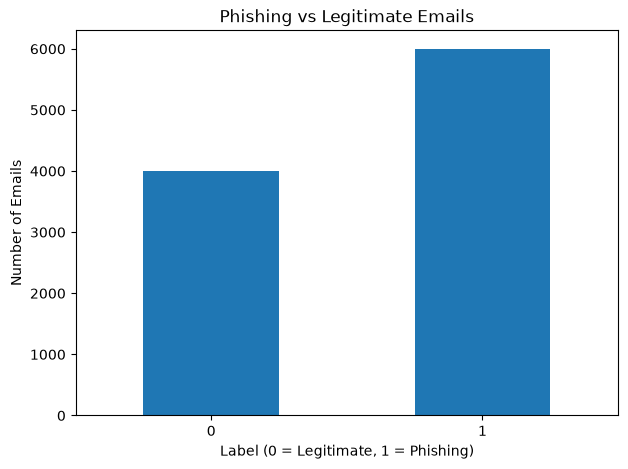

In [8]:
df["label"].value_counts().sort_index().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Phishing vs Legitimate Emails")
plt.xlabel("Label (0 = Legitimate, 1 = Phishing)")
plt.ylabel("Number of Emails")
plt.xticks(rotation=0)
plt.show()

In [9]:
df[df["label"] == 1][["text", "phishing_type"]].head()

,text,phishing_type
1,"Hello, your profile has been locked. Use the s...",credential_harvesting
2,"Hi there, congratulations! You are the winner ...",financial_scam
3,"Attention, this is the fraud prevention accoun...",authority_scam
4,"Notice, your profile has been restricted. Use ...",credential_harvesting
5,"Attention, this is an urgent notice regarding ...",urgency


In [10]:
df[df["label"] == 0][["text", "phishing_type"]].head()

,text,phishing_type
0,Subject: Office maintenance\n\nThanks for your...,legitimate
6,Subject: Training session notes\n\nI booked th...,legitimate
7,Subject: Meeting follow-up\n\nThanks for atten...,legitimate
8,"Subject: Research discussion\n\nGood morning, ...",legitimate
10,Subject: Classroom logistics\n\nSharing the re...,legitimate


## 3. Data Preprocessing

Data preprocessing is performed to convert raw email content into
clean and meaningful text suitable for Natural Language Processing.

The preprocessing steps include:

1. Handling missing values
2. Removing duplicate emails
3. Converting text to lowercase
4. Removing HTML tags
5. Removing URLs
6. Removing punctuation
7. Tokenization
8. Removing stopwords
9. Creating cleaned email text

In [11]:
print("Dataset shape:", df.shape)
print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

Dataset shape: (10000, 5)

Missing values:
text             0
label            0
phishing_type    0
severity         0
confidence       0
dtype: int64

Duplicate rows: 2


In [12]:
df = df.dropna(subset=["text"]).copy()

print("Dataset shape after removing missing emails:", df.shape)

Dataset shape after removing missing emails: (10000, 5)


In [13]:
df = df.drop_duplicates(subset=["text"]).copy()

print("Dataset shape after removing duplicates:", df.shape)

Dataset shape after removing duplicates: (9956, 5)


## 4. Metadata and Structural Feature Extraction

In addition to NLP text features, structural characteristics of
emails are extracted.

The features include:

- Email length
- Number of URLs
- Number of digits
- Number of special characters
- Number of exclamation marks
- Number of suspicious words

import re

In [14]:
def count_urls(text):
    return len(
        re.findall(
            r'https?://\S+|www\.\S+',
            str(text)
        )
    )

In [15]:
def email_length(text):
    return len(str(text))

In [16]:
def count_digits(text):
    return sum(char.isdigit() for char in str(text))

In [17]:
def count_special_characters(text):
    return sum(
        not char.isalnum() and not char.isspace()
        for char in str(text)
    )

In [18]:
def count_exclamation_marks(text):
    return str(text).count("!")

In [19]:
suspicious_words = [
    "urgent",
    "verify",
    "verification",
    "account",
    "suspended",
    "suspend",
    "click",
    "password",
    "login",
    "confirm",
    "security",
    "payment",
    "bank",
    "winner",
    "claim",
    "limited",
    "immediately",
    "expire",
    "expired",
    "update"
]

In [20]:
def count_suspicious_words(text):
    text = str(text).lower()
    
    return sum(
        text.count(word)
        for word in suspicious_words
    )

In [21]:
df["email_length"] = df["text"].apply(email_length)

df["url_count"] = df["text"].apply(count_urls)

df["digit_count"] = df["text"].apply(count_digits)

df["special_char_count"] = df["text"].apply(
    count_special_characters
)

df["exclamation_count"] = df["text"].apply(
    count_exclamation_marks
)

df["suspicious_word_count"] = df["text"].apply(
    count_suspicious_words
)

print("Metadata features created successfully!")

Metadata features created successfully!


In [22]:
df[
    [
        "text",
        "email_length",
        "url_count",
        "digit_count",
        "special_char_count",
        "exclamation_count",
        "suspicious_word_count"
    ]
].head()

,text,email_length,url_count,digit_count,special_char_count,exclamation_count,suspicious_word_count
0,Subject: Office maintenance\n\nThanks for your...,190,0,0,6,0,0
1,"Hello, your profile has been locked. Use the s...",222,0,0,6,0,5
2,"Hi there, congratulations! You are the winner ...",236,0,5,10,1,2
3,"Attention, this is the fraud prevention accoun...",321,0,0,8,0,4
4,"Notice, your profile has been restricted. Use ...",200,0,1,6,0,2


## 5. NLP Text Preprocessing

The email text is cleaned before feature extraction.

The following operations are performed:

1. Convert text to lowercase
2. Remove HTML tags
3. Remove URLs
4. Remove punctuation
5. Tokenize the text
6. Remove English stopwords
7. Reconstruct the cleaned text

In [23]:
nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Error loading stopwords: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading punkt: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>
[nltk_data] Error loading punkt_tab: <urlopen error [SSL:
[nltk_data]     CERTIFICATE_VERIFY_FAILED] certificate verify failed:
[nltk_data]     unable to get local issuer certificate (_ssl.c:1000)>


False

In [24]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

stop_words = set(stopwords.words("english"))

print("NLTK resources loaded successfully!")

LookupError: 
**********************************************************************
  Resource 'stopwords' not found.
  Please use the NLTK Downloader to obtain the resource:

  >>> import nltk
  >>> nltk.download('stopwords')

  For more information see: https://www.nltk.org/data.html

  Attempted to load 'corpora/stopwords'

  Searched in:
    - '/Users/mandeep/nltk_data'
    - '/Users/mandeep/Documents/AI-Phishing-Email-Detector/venv/nltk_data'
    - '/Users/mandeep/Documents/AI-Phishing-Email-Detector/venv/share/nltk_data'
    - '/Users/mandeep/Documents/AI-Phishing-Email-Detector/venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


In [25]:
import os
import certifi

os.environ["SSL_CERT_FILE"] = certifi.where()
os.environ["REQUESTS_CA_BUNDLE"] = certifi.where()

print("SSL certificate configured successfully!")

SSL certificate configured successfully!


In [26]:
import nltk

nltk.download("stopwords")
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mandeep/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package punkt to /Users/mandeep/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/mandeep/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [27]:
from nltk.corpus import stopwords

stop_words = set(stopwords.words("english"))

print("Number of English stopwords:", len(stop_words))
print("NLTK stopwords loaded successfully!")

Number of English stopwords: 198
NLTK stopwords loaded successfully!


In [28]:
def clean_text(text):
    text = str(text)

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", " ", text)

    # Remove URLs
    text = re.sub(
        r"https?://\S+|www\.\S+",
        " ",
        text
    )

    # Remove punctuation
    text = text.translate(
        str.maketrans("", "", string.punctuation)
    )

    # Tokenize
    tokens = word_tokenize(text)

    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]

    return " ".join(tokens)

In [29]:
sample_email = """
URGENT!!! Your account has been suspended.

Click https://example.com immediately
to verify your password.
"""

print("ORIGINAL EMAIL:")
print(sample_email)

print("\nCLEANED EMAIL:")
print(clean_text(sample_email))

ORIGINAL EMAIL:

URGENT!!! Your account has been suspended.

Click https://example.com immediately
to verify your password.


CLEANED EMAIL:
urgent account suspended click immediately verify password


In [30]:
df["clean_text"] = df["text"].apply(clean_text)

print("NLP preprocessing completed successfully!")

NLP preprocessing completed successfully!


In [31]:
df[["text", "clean_text"]].head()

,text,clean_text
0,Subject: Office maintenance\n\nThanks for your...,subject office maintenance thanks help analysi...
1,"Hello, your profile has been locked. Use the s...",hello profile locked use secure link verify us...
2,"Hi there, congratulations! You are the winner ...",hi congratulations winner refund collect gift ...
3,"Attention, this is the fraud prevention accoun...",attention fraud prevention accounts team secur...
4,"Notice, your profile has been restricted. Use ...",notice profile restricted use secure link rese...


In [32]:
empty_emails = (
    df["clean_text"]
    .str.strip()
    .eq("")
    .sum()
)

print("Empty cleaned emails:", empty_emails)

Empty cleaned emails: 0


In [33]:
df = df[
    df["clean_text"].str.strip() != ""
].copy()

print("Dataset shape:", df.shape)

Dataset shape: (9956, 12)


In [34]:
df.to_csv(
    "../dataset/processed/cleaned_emails.csv",
    index=False
)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


## 6. TF-IDF Feature Extraction

TF-IDF (Term Frequency-Inverse Document Frequency) is used to
convert cleaned email text into numerical feature vectors.

These numerical representations can then be provided to
machine-learning classification algorithms.

In [35]:
vectorizer = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2)
)

print("TF-IDF vectorizer created successfully!")

TF-IDF vectorizer created successfully!


In [36]:
X_tfidf = vectorizer.fit_transform(
    df["clean_text"]
)

print("TF-IDF feature extraction completed!")

TF-IDF feature extraction completed!


In [37]:
print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (9956, 5000)


In [38]:
feature_names = vectorizer.get_feature_names_out()

print("Number of features:", len(feature_names))
print("\nFirst 50 features:")
print(feature_names[:50])

Number of features: 5000

First 50 features:
['10000' '10000 compliance' '10000 please' '10000 security'
 '10000 sincerely' '1200' '1200 please' '24' '24 hours' '2500'
 '2500 please' '2fa' '2fa account' '2fa activation' '2fa authentication'
 '2fa change' '2fa code' '2fa desk' '2fa log' '2fa login' '2fa passcode'
 '2fa pin' '2fa recovery' '2fa regards' '2fa reset' '2fa security'
 '2fa sign' '2fa signin' '2fa sincerely' '2fa support' '2fa two'
 '2fa update' '2fa verification' '48' '48 hours' '5000' '5000 please'
 '80000' '80000 please' 'aboard' 'aboard attaching' 'aboard booked'
 'aboard good' 'aboard hello' 'aboard hi' 'aboard please' 'aboard quick'
 'aboard sharing' 'aboard thanks' 'access']


In [39]:
y = df["label"]

print("Target variable created successfully!")
print(y.value_counts())

Target variable created successfully!
label
1    6000
0    3956
Name: count, dtype: int64


In [40]:
print("0 = Legitimate")
print("1 = Phishing")

0 = Legitimate
1 = Phishing


In [41]:
metadata_features = [
    "email_length",
    "url_count",
    "digit_count",
    "special_char_count",
    "exclamation_count",
    "suspicious_word_count"
]

df[metadata_features].head()

,email_length,url_count,digit_count,special_char_count,exclamation_count,suspicious_word_count
0,190,0,0,6,0,0
1,222,0,0,6,0,5
2,236,0,5,10,1,2
3,321,0,0,8,0,4
4,200,0,1,6,0,2


In [42]:
print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (9956, 5000)


In [43]:
y.value_counts()

label
1    6000
0    3956
Name: count, dtype: int64

## 7. Combining Text and Metadata Features

The TF-IDF text features are combined with structural email features
to create a richer representation of each email.

The combined feature set contains both linguistic information and
email-level structural characteristics.

In [44]:
from scipy.sparse import hstack

In [45]:
metadata_matrix = df[metadata_features].values

print("Metadata matrix shape:", metadata_matrix.shape)

Metadata matrix shape: (9956, 6)


In [46]:
X_combined = hstack([
    X_tfidf,
    metadata_matrix
])

print("Combined feature matrix shape:", X_combined.shape)

Combined feature matrix shape: (9956, 5006)


In [47]:
print("Target variable shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts())

Target variable shape: (9956,)

Class distribution:
label
1    6000
0    3956
Name: count, dtype: int64


## 8. Train-Test Split

The dataset is divided into training and testing subsets.

The training set is used to train the machine-learning models,
while the testing set is used to evaluate their performance on
unseen email samples.

In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X_combined,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training labels:", y_train.shape)
print("Testing labels:", y_test.shape)

Training features: (7964, 5006)
Testing features: (1992, 5006)
Training labels: (7964,)
Testing labels: (1992,)


In [49]:
stratify=y

In [50]:
print("Training class distribution:")
print(y_train.value_counts())

print("\nTesting class distribution:")
print(y_test.value_counts())

Training class distribution:
label
1    4800
0    3164
Name: count, dtype: int64

Testing class distribution:
label
1    1200
0     792
Name: count, dtype: int64


## 9. Logistic Regression

Logistic Regression is used as the first classification model for
distinguishing between phishing and legitimate emails.

The model is trained using the combined TF-IDF and metadata features.

In [51]:
from sklearn.linear_model import LogisticRegression

In [52]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

print("Logistic Regression model created!")

Logistic Regression model created!


In [53]:
lr_model.fit(X_train, y_train)

print("Logistic Regression training completed!")

Logistic Regression training completed!


In [54]:
lr_pred = lr_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


In [55]:
print("Actual labels:")
print(y_test.values[:20])

print("\nPredicted labels:")
print(lr_pred[:20])

Actual labels:
[1 0 0 0 1 0 1 1 0 1 0 0 0 1 0 1 1 1 1 0]

Predicted labels:
[1 0 0 0 1 0 1 1 0 1 0 0 0 1 0 1 1 1 1 0]


In [56]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score
)

In [57]:
lr_accuracy = accuracy_score(y_test, lr_pred)

lr_precision = precision_score(
    y_test,
    lr_pred,
    average="weighted"
)

lr_recall = recall_score(
    y_test,
    lr_pred,
    average="weighted"
)

lr_f1 = f1_score(
    y_test,
    lr_pred,
    average="weighted"
)

print("Logistic Regression Results")
print("----------------------------")
print(f"Accuracy : {lr_accuracy:.4f}")
print(f"Precision: {lr_precision:.4f}")
print(f"Recall   : {lr_recall:.4f}")
print(f"F1 Score : {lr_f1:.4f}")

Logistic Regression Results
----------------------------
Accuracy : 0.9990
Precision: 0.9990
Recall   : 0.9990
F1 Score : 0.9990


In [58]:
lr_results = {
    "Model": "Logistic Regression",
    "Accuracy": lr_accuracy,
    "Precision": lr_precision,
    "Recall": lr_recall,
    "F1 Score": lr_f1
}

lr_results

{'Model': 'Logistic Regression',
 'Accuracy': 0.998995983935743,
 'Precision': 0.9989985129434615,
 'Recall': 0.998995983935743,
 'F1 Score': 0.9989961982960297}

## 10. Naive Bayes

Multinomial Naive Bayes is used as the second classification model.
It is particularly suitable for text classification because it can
work effectively with numerical representations such as TF-IDF features.

In [59]:
from sklearn.naive_bayes import MultinomialNB

In [60]:
nb_model = MultinomialNB()

print("Naive Bayes model created!")

Naive Bayes model created!


In [61]:
nb_model.fit(X_train, y_train)

print("Naive Bayes training completed!")

Naive Bayes training completed!


In [62]:
nb_pred = nb_model.predict(X_test)

print("Naive Bayes predictions generated!")

Naive Bayes predictions generated!


In [63]:
nb_accuracy = accuracy_score(y_test, nb_pred)

nb_precision = precision_score(
    y_test,
    nb_pred,
    average="weighted"
)

nb_recall = recall_score(
    y_test,
    nb_pred,
    average="weighted"
)

nb_f1 = f1_score(
    y_test,
    nb_pred,
    average="weighted"
)

print("Naive Bayes Results")
print("-------------------")
print(f"Accuracy : {nb_accuracy:.4f}")
print(f"Precision: {nb_precision:.4f}")
print(f"Recall   : {nb_recall:.4f}")
print(f"F1 Score : {nb_f1:.4f}")

Naive Bayes Results
-------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


In [64]:
nb_results = {
    "Model": "Naive Bayes",
    "Accuracy": nb_accuracy,
    "Precision": nb_precision,
    "Recall": nb_recall,
    "F1 Score": nb_f1
}

nb_results

{'Model': 'Naive Bayes',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1 Score': 1.0}

## 11. Initial Model Comparison

The performance of Logistic Regression and Naive Bayes is compared
using accuracy, precision, recall, and F1-score.

In [65]:
comparison_2 = pd.DataFrame([
    lr_results,
    nb_results
])

comparison_2

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.998996,0.998999,0.998996,0.998996
1,Naive Bayes,1.000000,1.000000,1.000000,1.000000


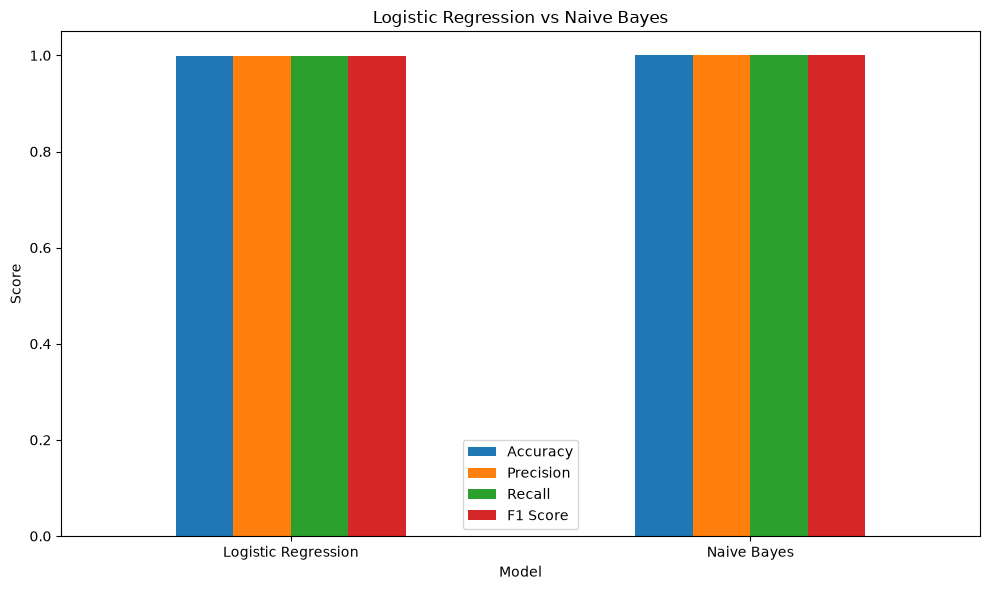

In [66]:
comparison_2.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Logistic Regression vs Naive Bayes")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

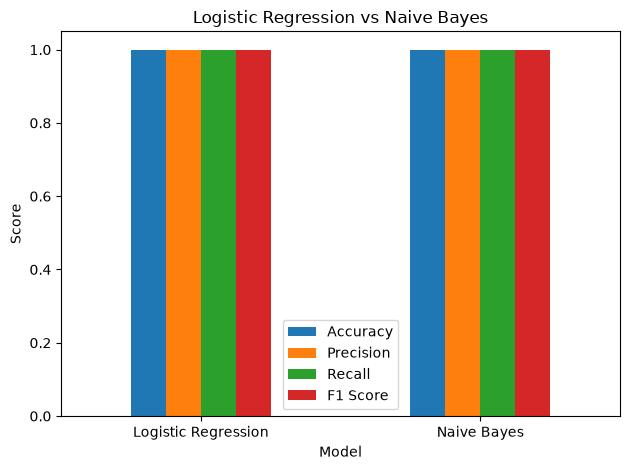

In [67]:
plt.figure(figsize=(10, 6))

comparison_2.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(kind="bar")

plt.title("Logistic Regression vs Naive Bayes")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "../results/logistic_vs_naive_bayes.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 12. Random Forest

Random Forest is used as the third classification model.

The model combines multiple decision trees to perform classification.
It is also useful for analysing the importance of individual features
in phishing email detection.

In [68]:
from sklearn.ensemble import RandomForestClassifier

In [69]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

print("Random Forest model created!")

Random Forest model created!


In [70]:
rf_model.fit(X_train, y_train)

print("Random Forest training completed!")

Random Forest training completed!


In [71]:
rf_pred = rf_model.predict(X_test)

print("Random Forest predictions generated!")

Random Forest predictions generated!


In [72]:
rf_accuracy = accuracy_score(y_test, rf_pred)

rf_precision = precision_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_recall = recall_score(
    y_test,
    rf_pred,
    average="weighted"
)

rf_f1 = f1_score(
    y_test,
    rf_pred,
    average="weighted"
)

print("Random Forest Results")
print("---------------------")
print(f"Accuracy : {rf_accuracy:.4f}")
print(f"Precision: {rf_precision:.4f}")
print(f"Recall   : {rf_recall:.4f}")
print(f"F1 Score : {rf_f1:.4f}")

Random Forest Results
---------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


In [73]:
rf_results = {
    "Model": "Random Forest",
    "Accuracy": rf_accuracy,
    "Precision": rf_precision,
    "Recall": rf_recall,
    "F1 Score": rf_f1
}

rf_results

{'Model': 'Random Forest',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1 Score': 1.0}

## 13. Three-Model Performance Comparison

The performance of Logistic Regression, Naive Bayes, and Random
Forest is compared using accuracy, precision, recall, and F1-score.

In [74]:
comparison_3 = pd.DataFrame([
    lr_results,
    nb_results,
    rf_results
])

comparison_3

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.998996,0.998999,0.998996,0.998996
1,Naive Bayes,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000


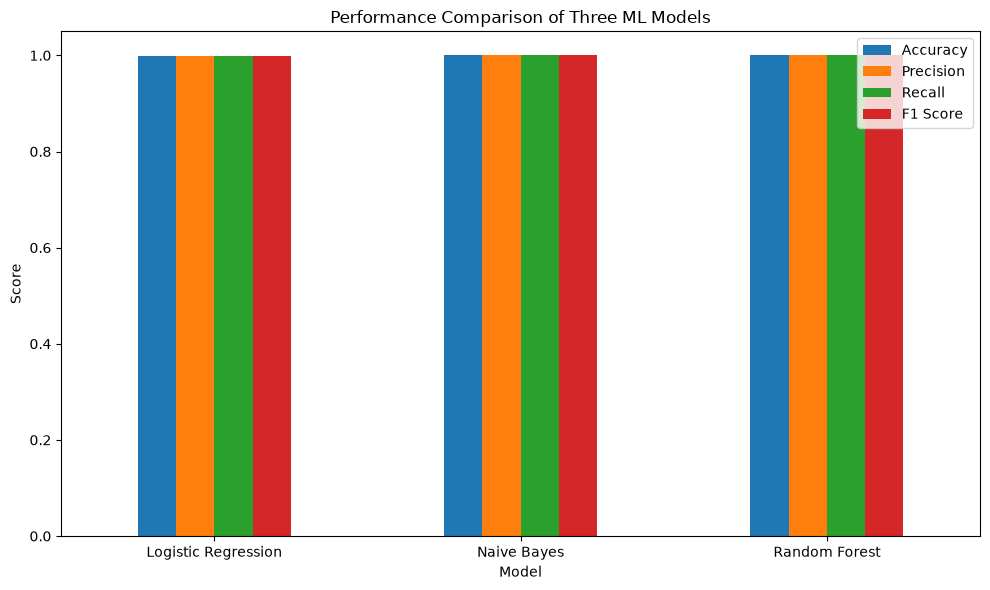

In [75]:
comparison_3.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Performance Comparison of Three ML Models")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1000x600 with 0 Axes>

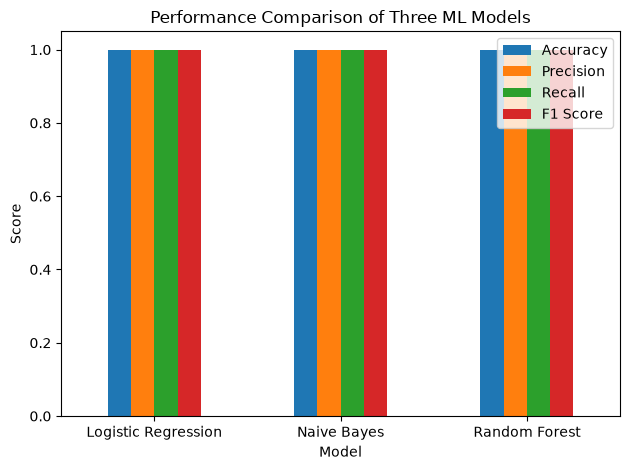

In [76]:
plt.figure(figsize=(10, 6))

comparison_3.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(kind="bar")

plt.title("Performance Comparison of Three ML Models")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "../results/three_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 14. Random Forest Feature Importance

Feature importance is analysed to identify which TF-IDF terms and
structural email characteristics contribute most to the Random Forest
classification decisions.

In [77]:
all_feature_names = list(feature_names) + metadata_features

print("Total feature names:", len(all_feature_names))
print("Random Forest features:", len(rf_model.feature_importances_))

Total feature names: 5006
Random Forest features: 5006


In [78]:
feature_importance = pd.DataFrame({
    "Feature": all_feature_names,
    "Importance": rf_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

feature_importance.head(20)

,Feature,Importance
2204,keywords,0.066202
5000,email_length,0.054134
4227,subject,0.047081
530,best,0.047054
5005,suspicious_word_count,0.040359
58,account,0.024222
5003,special_char_count,0.022228
1522,feedback,0.016036
2964,notes,0.014254
4430,thanks,0.013829


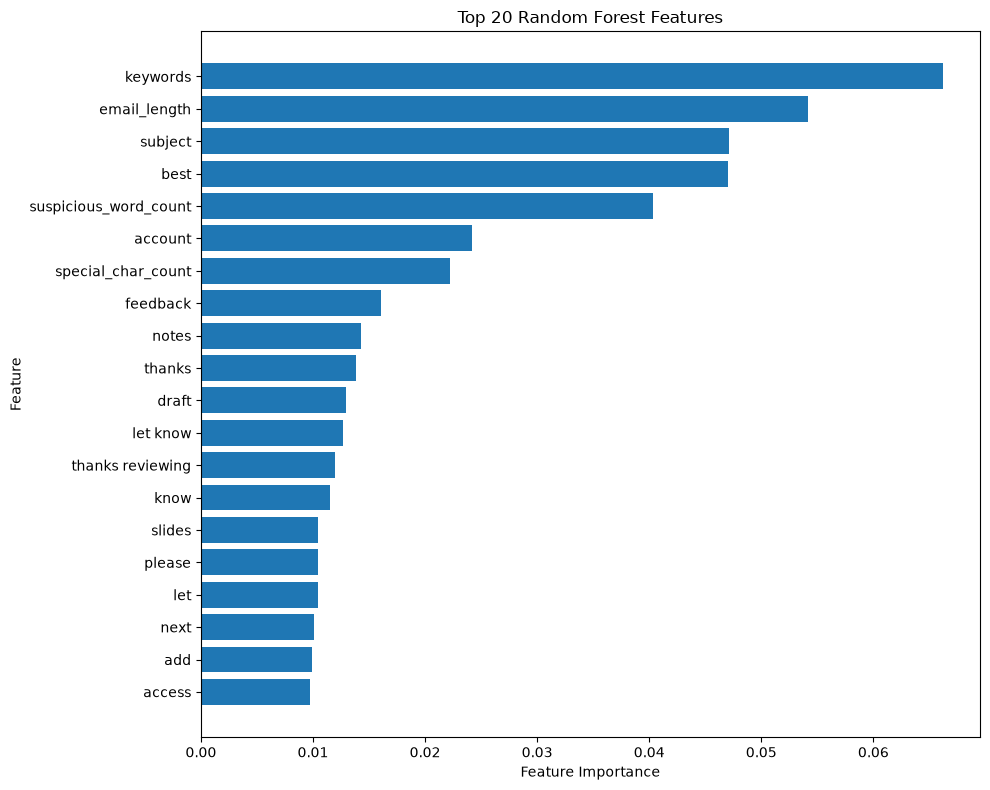

In [79]:
top_features = feature_importance.head(20)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 20 Random Forest Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

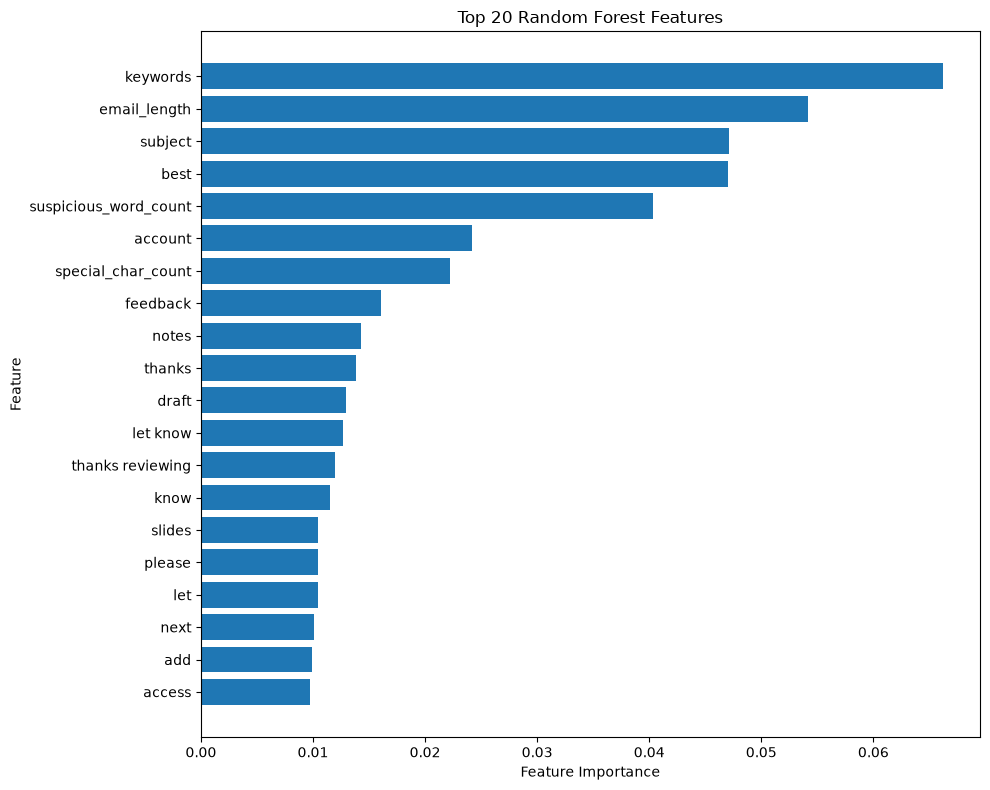

In [80]:
plt.figure(figsize=(10, 8))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.title("Top 20 Random Forest Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()

plt.savefig(
    "../results/random_forest_feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 15. Simple Neural Network

A simple feed-forward neural network is developed using a Multi-Layer
Perceptron classifier.

The neural network is trained using the combined TF-IDF and structural
email features and evaluated using accuracy, precision, recall, and
F1-score.

In [81]:
from sklearn.neural_network import MLPClassifier

print("Neural Network library loaded successfully!")

Neural Network library loaded successfully!


In [82]:
nn_model = MLPClassifier(
    hidden_layer_sizes=(64,),
    activation="relu",
    solver="adam",
    max_iter=50,
    early_stopping=True,
    random_state=42
)

print("Neural Network model created!")

Neural Network model created!


In [83]:
nn_model.fit(X_train, y_train)

print("Neural Network training completed!")

Neural Network training completed!


In [84]:
nn_pred = nn_model.predict(X_test)

print("Neural Network predictions generated!")

Neural Network predictions generated!


In [85]:
nn_accuracy = accuracy_score(y_test, nn_pred)

nn_precision = precision_score(
    y_test,
    nn_pred,
    average="weighted"
)

nn_recall = recall_score(
    y_test,
    nn_pred,
    average="weighted"
)

nn_f1 = f1_score(
    y_test,
    nn_pred,
    average="weighted"
)

print("Neural Network Results")
print("----------------------")
print(f"Accuracy : {nn_accuracy:.4f}")
print(f"Precision: {nn_precision:.4f}")
print(f"Recall   : {nn_recall:.4f}")
print(f"F1 Score : {nn_f1:.4f}")

Neural Network Results
----------------------
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000


In [86]:
nn_results = {
    "Model": "Neural Network",
    "Accuracy": nn_accuracy,
    "Precision": nn_precision,
    "Recall": nn_recall,
    "F1 Score": nn_f1
}

nn_results

{'Model': 'Neural Network',
 'Accuracy': 1.0,
 'Precision': 1.0,
 'Recall': 1.0,
 'F1 Score': 1.0}

## 16. Final Model Comparison

The four machine-learning models are compared using accuracy,
precision, recall, and F1-score to determine the most suitable model
for phishing email classification.

In [87]:
final_comparison = pd.DataFrame([
    lr_results,
    nb_results,
    rf_results,
    nn_results
])

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.998996,0.998999,0.998996,0.998996
1,Naive Bayes,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000
3,Neural Network,1.000000,1.000000,1.000000,1.000000


In [88]:
best_model = final_comparison.loc[
    final_comparison["F1 Score"].idxmax()
]

print("Best model based on F1 Score:")
print(best_model)

Best model based on F1 Score:
Model        Naive Bayes
Accuracy             1.0
Precision            1.0
Recall               1.0
F1 Score             1.0
Name: 1, dtype: object


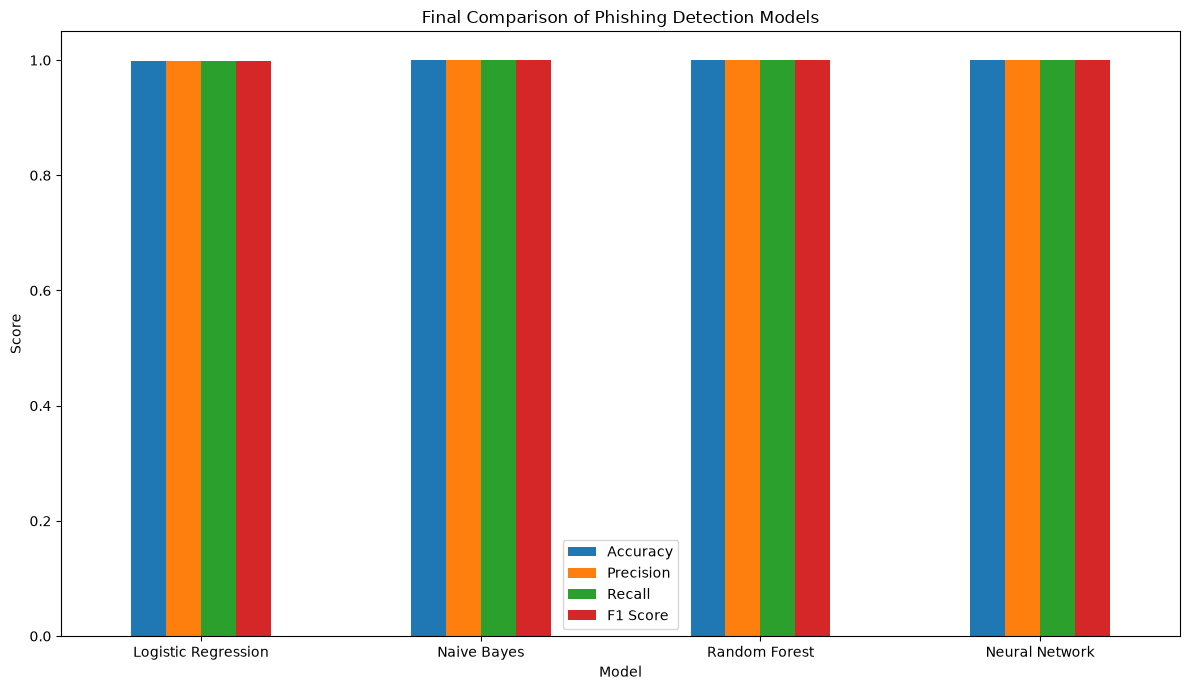

In [89]:
final_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(
    kind="bar",
    figsize=(12, 7)
)

plt.title("Final Comparison of Phishing Detection Models")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<Figure size 1200x700 with 0 Axes>

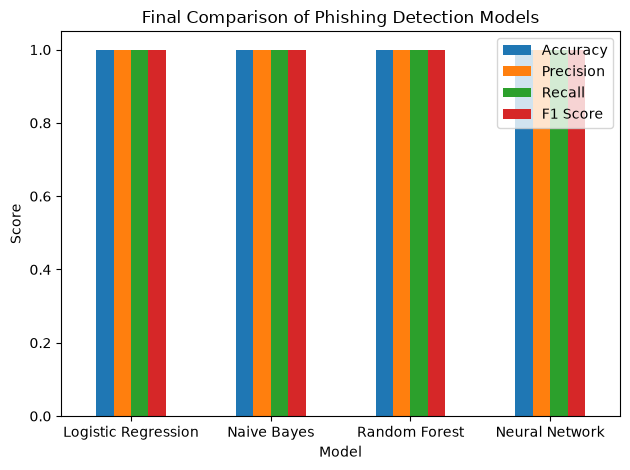

In [90]:
plt.figure(figsize=(12, 7))

final_comparison.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1 Score"]
].plot(kind="bar")

plt.title("Final Comparison of Phishing Detection Models")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=0)
plt.tight_layout()

plt.savefig(
    "../results/final_model_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 17. Confusion Matrix Analysis

Confusion matrices are used to analyse correct and incorrect
classification results for each machine-learning model.

The analysis focuses on true positives, true negatives, false
positives, and false negatives.

In [91]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

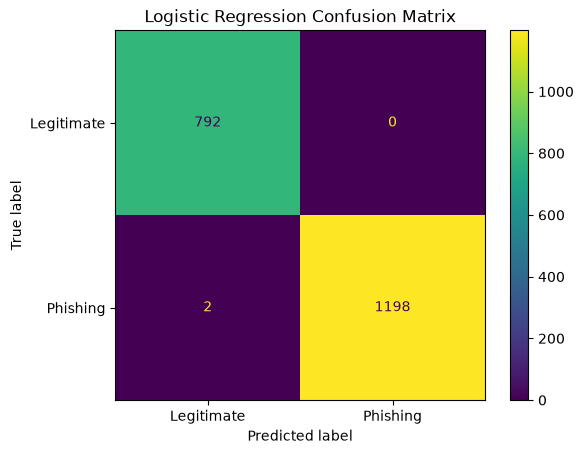

In [92]:
cm_lr = confusion_matrix(y_test, lr_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_lr,
    display_labels=["Legitimate", "Phishing"]
)

disp.plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()

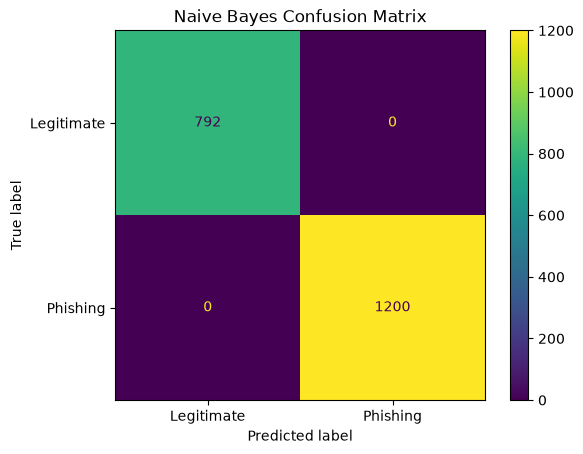

In [93]:
cm_nb = confusion_matrix(y_test, nb_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nb,
    display_labels=["Legitimate", "Phishing"]
)

disp.plot()
plt.title("Naive Bayes Confusion Matrix")
plt.show()

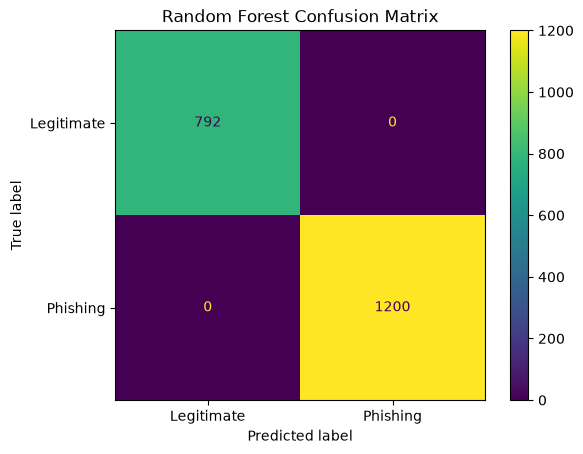

In [94]:
cm_rf = confusion_matrix(y_test, rf_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_rf,
    display_labels=["Legitimate", "Phishing"]
)

disp.plot()
plt.title("Random Forest Confusion Matrix")
plt.show()

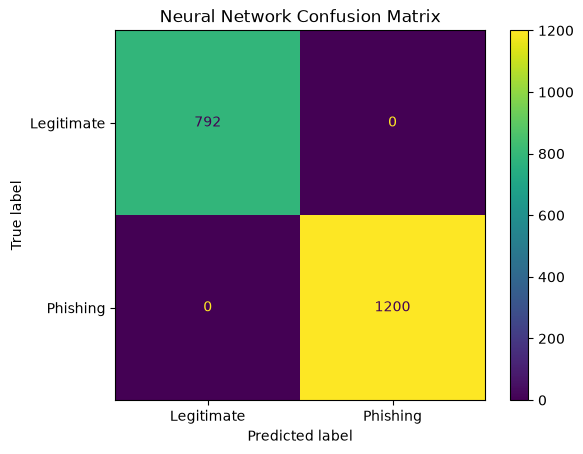

In [95]:
cm_nn = confusion_matrix(y_test, nn_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_nn,
    display_labels=["Legitimate", "Phishing"]
)

disp.plot()
plt.title("Neural Network Confusion Matrix")
plt.show()

## 18. Detailed Classification Reports

Classification reports are generated for all four models to provide
class-wise precision, recall, F1-score, and support.

In [96]:
from sklearn.metrics import classification_report

In [97]:
print("===== LOGISTIC REGRESSION =====")

print(
    classification_report(
        y_test,
        lr_pred,
        target_names=["Legitimate", "Phishing"]
    )
)

===== LOGISTIC REGRESSION =====
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       792
    Phishing       1.00      1.00      1.00      1200

    accuracy                           1.00      1992
   macro avg       1.00      1.00      1.00      1992
weighted avg       1.00      1.00      1.00      1992



In [98]:
print("===== NAIVE BAYES =====")

print(
    classification_report(
        y_test,
        nb_pred,
        target_names=["Legitimate", "Phishing"]
    )
)

===== NAIVE BAYES =====
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       792
    Phishing       1.00      1.00      1.00      1200

    accuracy                           1.00      1992
   macro avg       1.00      1.00      1.00      1992
weighted avg       1.00      1.00      1.00      1992



In [99]:
print("===== RANDOM FOREST =====")

print(
    classification_report(
        y_test,
        rf_pred,
        target_names=["Legitimate", "Phishing"]
    )
)

===== RANDOM FOREST =====
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       792
    Phishing       1.00      1.00      1.00      1200

    accuracy                           1.00      1992
   macro avg       1.00      1.00      1.00      1992
weighted avg       1.00      1.00      1.00      1992



In [100]:
print("===== NEURAL NETWORK =====")

print(
    classification_report(
        y_test,
        nn_pred,
        target_names=["Legitimate", "Phishing"]
    )
)

===== NEURAL NETWORK =====
              precision    recall  f1-score   support

  Legitimate       1.00      1.00      1.00       792
    Phishing       1.00      1.00      1.00      1200

    accuracy                           1.00      1992
   macro avg       1.00      1.00      1.00      1992
weighted avg       1.00      1.00      1.00      1992



## 19. ROC-AUC Analysis

ROC curves and Area Under the Curve (AUC) are used to analyse the
ability of each classifier to distinguish between legitimate and
phishing emails across different classification thresholds.

In [101]:
from sklearn.metrics import roc_curve, roc_auc_score

In [102]:
lr_prob = lr_model.predict_proba(X_test)[:, 1]

In [103]:
nb_prob = nb_model.predict_proba(X_test)[:, 1]

In [104]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

In [105]:
nn_prob = nn_model.predict_proba(X_test)[:, 1]

In [106]:
lr_prob = lr_model.predict_proba(X_test)[:, 1]
nb_prob = nb_model.predict_proba(X_test)[:, 1]
rf_prob = rf_model.predict_proba(X_test)[:, 1]
nn_prob = nn_model.predict_proba(X_test)[:, 1]

print("Prediction probabilities generated successfully!")

Prediction probabilities generated successfully!


In [107]:
lr_auc = roc_auc_score(y_test, lr_prob)
nb_auc = roc_auc_score(y_test, nb_prob)
rf_auc = roc_auc_score(y_test, rf_prob)
nn_auc = roc_auc_score(y_test, nn_prob)

print("ROC-AUC Scores")
print("----------------")
print(f"Logistic Regression: {lr_auc:.4f}")
print(f"Naive Bayes:        {nb_auc:.4f}")
print(f"Random Forest:      {rf_auc:.4f}")
print(f"Neural Network:     {nn_auc:.4f}")

ROC-AUC Scores
----------------
Logistic Regression: 1.0000
Naive Bayes:        1.0000
Random Forest:      1.0000
Neural Network:     1.0000


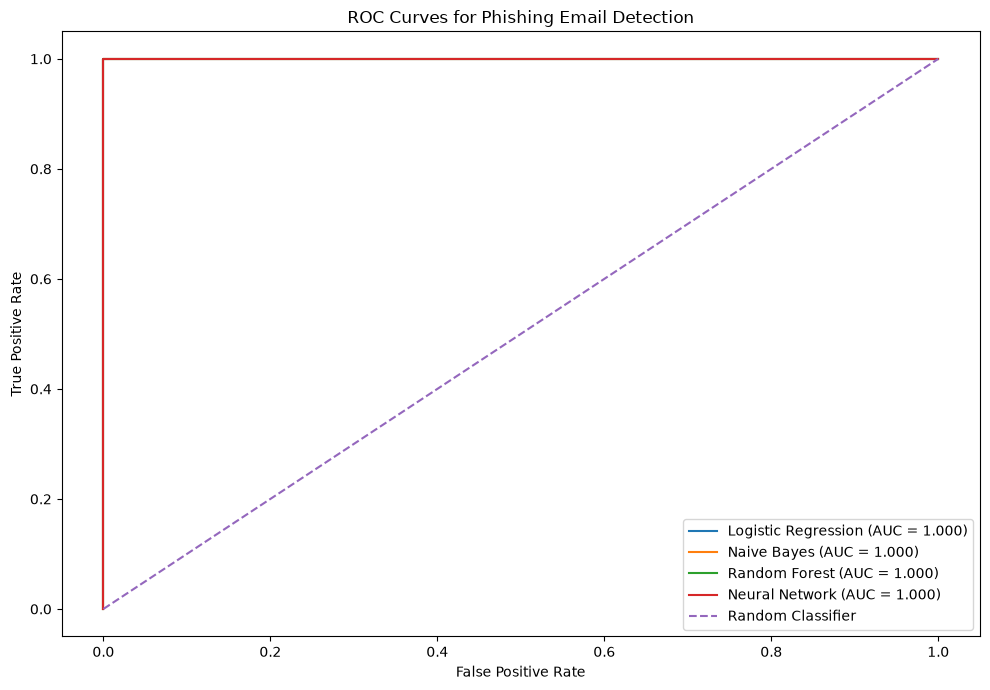

In [108]:
lr_fpr, lr_tpr, _ = roc_curve(y_test, lr_prob)
nb_fpr, nb_tpr, _ = roc_curve(y_test, nb_prob)
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)
nn_fpr, nn_tpr, _ = roc_curve(y_test, nn_prob)

plt.figure(figsize=(10, 7))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    nb_fpr,
    nb_tpr,
    label=f"Naive Bayes (AUC = {nb_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    nn_fpr,
    nn_tpr,
    label=f"Neural Network (AUC = {nn_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Phishing Email Detection")
plt.legend()
plt.tight_layout()
plt.show()

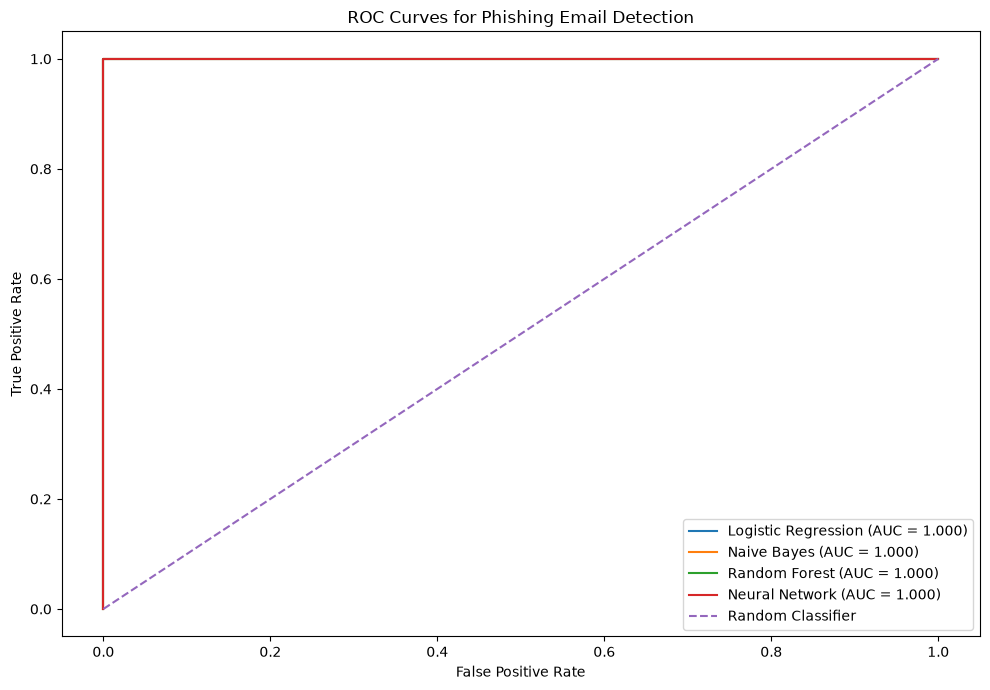

In [109]:
plt.figure(figsize=(10, 7))

plt.plot(
    lr_fpr,
    lr_tpr,
    label=f"Logistic Regression (AUC = {lr_auc:.3f})"
)

plt.plot(
    nb_fpr,
    nb_tpr,
    label=f"Naive Bayes (AUC = {nb_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

plt.plot(
    nn_fpr,
    nn_tpr,
    label=f"Neural Network (AUC = {nn_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves for Phishing Email Detection")
plt.legend()
plt.tight_layout()

plt.savefig(
    "../results/roc_auc_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [110]:
auc_results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Naive Bayes",
        "Random Forest",
        "Neural Network"
    ],
    "ROC-AUC": [
        lr_auc,
        nb_auc,
        rf_auc,
        nn_auc
    ]
})

auc_results

,Model,ROC-AUC
0,Logistic Regression,0.999993
1,Naive Bayes,1.000000
2,Random Forest,1.000000
3,Neural Network,1.000000


In [111]:
final_results = final_comparison.merge(
    auc_results,
    on="Model"
)

final_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.998996,0.998999,0.998996,0.998996,0.999993
1,Naive Bayes,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
3,Neural Network,1.000000,1.000000,1.000000,1.000000,1.000000


In [112]:
best_model_name = final_results.loc[
    final_results["F1 Score"].idxmax(),
    "Model"
]

print("Best model based on F1 Score:")
print(best_model_name)

Best model based on F1 Score:
Naive Bayes


In [113]:
best_model_row = final_results[
    final_results["Model"] == best_model_name
]

best_model_row

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
1,Naive Bayes,1.0,1.0,1.0,1.0,1.0


In [114]:
final_results.to_csv(
    "../results/final_model_results.csv",
    index=False
)

print("Final model results saved successfully!")

Final model results saved successfully!


## 20. Final Model Selection and Serialization

The best-performing classifier is selected based on the evaluation
results and saved for use in the phishing email detection application.

In [115]:
trained_models = {
    "Logistic Regression": lr_model,
    "Naive Bayes": nb_model,
    "Random Forest": rf_model,
    "Neural Network": nn_model
}

best_model = trained_models[best_model_name]

print("Selected model:", best_model_name)

Selected model: Naive Bayes


In [116]:
import joblib

joblib.dump(
    best_model,
    "../models/best_phishing_model.pkl"
)

print("Best model saved successfully!")

Best model saved successfully!


In [117]:
joblib.dump(
    vectorizer,
    "../models/tfidf_vectorizer.pkl"
)

print("TF-IDF vectorizer saved successfully!")

TF-IDF vectorizer saved successfully!


In [118]:
final_results

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.998996,0.998999,0.998996,0.998996,0.999993
1,Naive Bayes,1.000000,1.000000,1.000000,1.000000,1.000000
2,Random Forest,1.000000,1.000000,1.000000,1.000000,1.000000
3,Neural Network,1.000000,1.000000,1.000000,1.000000,1.000000


In [119]:
print("Best model based on F1 Score:")
print(best_model_name)

Best model based on F1 Score:
Naive Bayes


## 21. Phishing Email Prediction Pipeline

A prediction pipeline is created to process a new unseen email using
the same preprocessing, TF-IDF transformation, structural features,
and trained classification model used during training.

In [120]:
def extract_metadata(text):
    text = str(text)

    features = {
        "email_length": len(text),
        "url_count": len(
            re.findall(r"https?://\S+|www\.\S+", text)
        ),
        "digit_count": sum(
            char.isdigit() for char in text
        ),
        "special_char_count": sum(
            not char.isalnum() and not char.isspace()
            for char in text
        ),
        "exclamation_count": text.count("!"),
        "suspicious_word_count": sum(
            word in text.lower()
            for word in [
                "urgent",
                "verify",
                "password",
                "account",
                "click",
                "login",
                "confirm",
                "suspended",
                "security",
                "payment"
            ]
        )
    }

    return features

In [121]:
test_email = """
URGENT! Your account has been suspended.
Please verify your password immediately.
Click https://example.com/login to restore access.
"""

test_metadata = extract_metadata(test_email)

test_metadata

{'email_length': 134,
 'url_count': 1,
 'digit_count': 0,
 'special_char_count': 9,
 'exclamation_count': 1,
 'suspicious_word_count': 7}

In [122]:
def predict_email(email_text):

    # -----------------------------
    # 1. Clean the email
    # -----------------------------
    cleaned = clean_text(email_text)

    # -----------------------------
    # 2. Convert text to TF-IDF
    # -----------------------------
    text_features = vectorizer.transform([cleaned])

    # -----------------------------
    # 3. Extract metadata
    # -----------------------------
    metadata = extract_metadata(email_text)

    metadata_df = pd.DataFrame(
        [metadata],
        columns=metadata_features
    )

    # -----------------------------
    # 4. Combine TF-IDF + metadata
    # -----------------------------
    combined_features = hstack([
        text_features,
        metadata_df.values
    ])

    # -----------------------------
    # 5. Make prediction
    # -----------------------------
    prediction = best_model.predict(
        combined_features
    )[0]

    # -----------------------------
    # 6. Get confidence
    # -----------------------------
    probabilities = best_model.predict_proba(
        combined_features
    )[0]

    confidence = probabilities[prediction]

    # -----------------------------
    # 7. Convert label
    # -----------------------------
    if prediction == 1:
        label = "PHISHING"
    else:
        label = "LEGITIMATE"

    return {
        "prediction": int(prediction),
        "label": label,
        "confidence": float(confidence),
        "metadata": metadata
    }

In [123]:
phishing_test = """
URGENT SECURITY ALERT!

Your bank account has been suspended.

You must verify your password immediately.
Click https://example.com/login to restore your account.

Failure to verify your account within 24 hours
will result in permanent suspension.
"""

result = predict_email(phishing_test)

result

{'prediction': 1,
 'label': 'PHISHING',
 'confidence': 1.0,
 'metadata': {'email_length': 249,
  'url_count': 1,
  'digit_count': 2,
  'special_char_count': 10,
  'exclamation_count': 1,
  'suspicious_word_count': 8}}

In [124]:
print("===================================")
print("       PHISHING EMAIL DETECTOR")
print("===================================")

print("Prediction :", result["label"])
print(
    "Confidence :",
    f"{result['confidence'] * 100:.2f}%"
)

print("\nEmail Features:")
for key, value in result["metadata"].items():
    print(f"{key}: {value}")

       PHISHING EMAIL DETECTOR
Prediction : PHISHING
Confidence : 100.00%

Email Features:
email_length: 249
url_count: 1
digit_count: 2
special_char_count: 10
exclamation_count: 1
suspicious_word_count: 8


In [125]:
legitimate_test = """
Hi Rahul,

The meeting has been scheduled for tomorrow at 10:00 AM.
Please bring the project report and presentation.

Regards,
Project Team
"""

legitimate_result = predict_email(legitimate_test)

print("Prediction :", legitimate_result["label"])
print(
    "Confidence :",
    f"{legitimate_result['confidence'] * 100:.2f}%"
)

Prediction : LEGITIMATE
Confidence : 85.23%


In [126]:
phishing_test_2 = """
Congratulations! You have won a $5000 reward.

To claim your prize, confirm your account information
and login credentials immediately.

Click www.example.com/claim now.
"""

result_2 = predict_email(phishing_test_2)

print("Prediction :", result_2["label"])
print(
    "Confidence :",
    f"{result_2['confidence'] * 100:.2f}%"
)

Prediction : PHISHING
Confidence : 100.00%


In [127]:
joblib.dump(
    metadata_features,
    "../models/metadata_features.pkl"
)

joblib.dump(
    stop_words,
    "../models/stop_words.pkl"
)

print("Prediction pipeline components saved!")

Prediction pipeline components saved!


In [128]:
loaded_model = joblib.load(
    "../models/best_phishing_model.pkl"
)

loaded_vectorizer = joblib.load(
    "../models/tfidf_vectorizer.pkl"
)

loaded_metadata_features = joblib.load(
    "../models/metadata_features.pkl"
)

loaded_stop_words = joblib.load(
    "../models/stop_words.pkl"
)

print("All saved components loaded successfully!")

All saved components loaded successfully!


In [129]:
print("Loaded model:", type(loaded_model).__name__)
print("Number of TF-IDF features:",
      len(loaded_vectorizer.get_feature_names_out()))
print("Metadata features:",
      loaded_metadata_features)

Loaded model: MultinomialNB
Number of TF-IDF features: 5000
Metadata features: ['email_length', 'url_count', 'digit_count', 'special_char_count', 'exclamation_count', 'suspicious_word_count']
